<a href="https://colab.research.google.com/github/mikikonomiya/olympic-data-analysis/blob/main/gdp_and_dominance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Preparation

In [ ]:
# cleaned_olympic_nation_year

import pandas as pd

# 1. Load the dataset
df = pd.read_csv('athlete_events.csv')

# 2. Filter for only Medal winners
medals_only = df.dropna(subset=['Medal']).copy()

# 3. Collapse team medals
# A single medal win is unique to a Year, Season, Event, NOC, and Medal type
unique_event_wins = medals_only.drop_duplicates(
    subset=['Year', 'Season', 'Sport', 'Event', 'NOC', 'Medal']
)

# 4. Aggregate by nation and year (unique ID is NOC + Year)
nation_year_df = unique_event_wins.groupby(['NOC', 'Year', 'Season']).agg(
    Gold=('Medal', lambda x: (x == 'Gold').sum()),
    Silver=('Medal', lambda x: (x == 'Silver').sum()),
    Bronze=('Medal', lambda x: (x == 'Bronze').sum()),
    Total_Medals=('Medal', 'count'),
    # This captures the unique sports for your network analysis later
    Sports_List=('Sport', lambda x: list(set(x)))
).reset_index()

# 5. Save the csv
output_filename = "cleaned_olympic_nation_year.csv"
nation_year_df.to_csv(output_filename, index=False)

print(f"Success! Cleaned dataset saved as: {output_filename}")
print(nation_year_df.head())

Success! Cleaned dataset saved as: cleaned_olympic_nation_year.csv
   NOC  Year  Season  Gold  Silver  Bronze  Total_Medals          Sports_List
0  AFG  2008  Summer     0       0       1             1          [Taekwondo]
1  AFG  2012  Summer     0       0       1             1          [Taekwondo]
2  AHO  1988  Summer     0       1       0             1            [Sailing]
3  ALG  1984  Summer     0       0       2             2             [Boxing]
4  ALG  1992  Summer     1       0       1             2  [Boxing, Athletics]


In [ ]:
# cleaned_olympic_nation_participation

import pandas as pd

# 1. Load the dataset
df = pd.read_csv('athlete_events.csv')

# 2. Identify all participation
# A country participated if they had at least one athlete in an Event/Year/Season.
participation = df.drop_duplicates(subset=['Year', 'Season', 'Sport', 'Event', 'NOC']).copy()

# 3. Calculate medals
medals = df.dropna(subset=['Medal']).drop_duplicates(
    subset=['Year', 'Season', 'Sport', 'Event', 'NOC', 'Medal']
)

# 4. Aggregate participation
nation_year_df = participation.groupby(['NOC', 'Year', 'Season']).agg(
    Sports_Attempted=('Sport', lambda x: list(set(x))),
    Event_Entries=('Event', 'count')
).reset_index()

# 5. Aggregate medals
medal_counts = medals.groupby(['NOC', 'Year', 'Season']).agg(
    Gold=('Medal', lambda x: (x == 'Gold').sum()),
    Silver=('Medal', lambda x: (x == 'Silver').sum()),
    Bronze=('Medal', lambda x: (x == 'Bronze').sum()),
    Total_Medals=('Medal', 'count'),
    Sports_Won=('Sport', lambda x: list(set(x)))
).reset_index()

# 6. Merge participation with medals
final_df = pd.merge(nation_year_df, medal_counts, on=['NOC', 'Year', 'Season'], how='left')

# 7. Fill zeros and empty lists
cols_to_fix = ['Gold', 'Silver', 'Bronze', 'Total_Medals']
final_df[cols_to_fix] = final_df[cols_to_fix].fillna(0).astype(int)
final_df['Sports_Won'] = final_df['Sports_Won'].apply(lambda d: d if isinstance(d, list) else [])

# 8. SAVE
output_filename = "cleaned_olympic_nation_participation.csv"
final_df.to_csv(output_filename, index=False)

print(f"Success! Dataset includes zero-medal years. Total rows: {len(final_df)}")
print(final_df.head())

Success! Dataset includes zero-medal years. Total rows: 3837
   NOC  Year  Season        Sports_Attempted  Event_Entries  Gold  Silver  \
0  AFG  1936  Summer     [Hockey, Athletics]              4     0       0   
1  AFG  1948  Summer      [Football, Hockey]              2     0       0   
2  AFG  1956  Summer                [Hockey]              1     0       0   
3  AFG  1960  Summer  [Athletics, Wrestling]             13     0       0   
4  AFG  1964  Summer             [Wrestling]              8     0       0   

   Bronze  Total_Medals Sports_Won  
0       0             0         []  
1       0             0         []  
2       0             0         []  
3       0             0         []  
4       0             0         []  


In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import numpy as np

# 1. Load datasets
try:
    nation_df = pd.read_csv('cleaned_olympic_nation_participation.csv')
    gdp_raw = pd.read_csv('GDP.csv')
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure both CSV files are in the same folder.")
    exit()

# 2. Successor state mapping
historical_to_iso = {
    'GER': 'DEU', 'FRG': 'DEU', 'GDR': 'DEU', 'SAA': 'DEU',
    'URS': 'RUS', 'EUN': 'RUS', 'ROC': 'RUS',
    'TCH': 'CZE', 'BOH': 'CZE',
    'YUG': 'SRB', 'SCG': 'SRB',
    'GRE': 'GRC', 'NED': 'NLD', 'INA': 'IDN', 'SUI': 'CHE',
    'RSA': 'ZAF', 'NGR': 'NGA', 'DEN': 'DNK', 'CHI': 'CHL'
}
nation_df['ISO_Code'] = nation_df['NOC'].map(historical_to_iso).fillna(nation_df['NOC'])

# 3. Time bins
window = 8
nation_df['Period'] = nation_df['Year'].apply(lambda y: f"{int(y//window*window)}-{int(y//window*window+window)}")

# 4. Aggregate sports won
def combine_sports(series):
    combined = []
    for s_list in series:
        if isinstance(s_list, str):
            try:
                combined.extend(eval(s_list))
            except: pass
    return list(set(combined))

nation_grouped = nation_df.groupby(['ISO_Code', 'Period']).agg({
    'Sports_Won': combine_sports,
    'Total_Medals': 'sum'
}).reset_index()

# 5. Network centrality calculation
def get_centrality(df_period):
    """
    Creates a projection graph where nodes are nations and edges represent
    shared sports where both nations won medals.
    """
    sport_to_nations = {}
    for _, row in df_period.iterrows():
        for sport in row['Sports_Won']:
            sport_to_nations.setdefault(sport, []).append(row['ISO_Code'])

    edge_counts = Counter()
    for nations in sport_to_nations.values():
        for u, v in combinations(set(nations), 2):
            edge_counts[tuple(sorted((u, v)))] += 1

    G = nx.Graph()
    for (u, v), w in edge_counts.items():
        G.add_edge(u, v, weight=w)

    return nx.eigenvector_centrality(G, weight='weight', max_iter=2000) if len(G) > 0 else {}

centrality_list = []
for period, group in nation_grouped.groupby('Period'):
    scores = get_centrality(group)
    for iso, score in scores.items():
        centrality_list.append({'ISO_Code': iso, 'Period': period, 'Dominance': score})
centrality_df = pd.DataFrame(centrality_list)

# 6. Prep GDP data
gdp_melted = gdp_raw.melt(id_vars=['Country Code'], var_name='Year', value_name='GDP')

gdp_melted['GDP'] = pd.to_numeric(gdp_melted['GDP'].astype(str).str.replace(',', ''), errors='coerce')
gdp_melted['Year'] = pd.to_numeric(gdp_melted['Year'], errors='coerce')
gdp_melted = gdp_melted.dropna(subset=['GDP', 'Year'])

gdp_melted['Period'] = gdp_melted['Year'].apply(lambda y: f"{int(y//window*window)}-{int(y//window*window+window)}")
avg_gdp = gdp_melted.groupby(['Country Code', 'Period'])['GDP'].mean().reset_index()

# 7. Final merge and cleaning
final_df = pd.merge(centrality_df, avg_gdp, left_on=['ISO_Code', 'Period'], right_on=['Country Code', 'Period'])

final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['GDP', 'Dominance'])
final_df = final_df[final_df['Period'] != '2016-2024']

final_df = final_df.drop(columns=['Country Code'])

# 8. Save the dataset
output_filename = "centrality_and_gdp.csv"
final_df.to_csv(output_filename, index=False)
print(f"Success! Dataset saved as {output_filename}")
print(f"Total records processed: {len(final_df)}")

Success! Dataset saved as centrality_and_gdp.csv
Total records processed: 373


# The Network

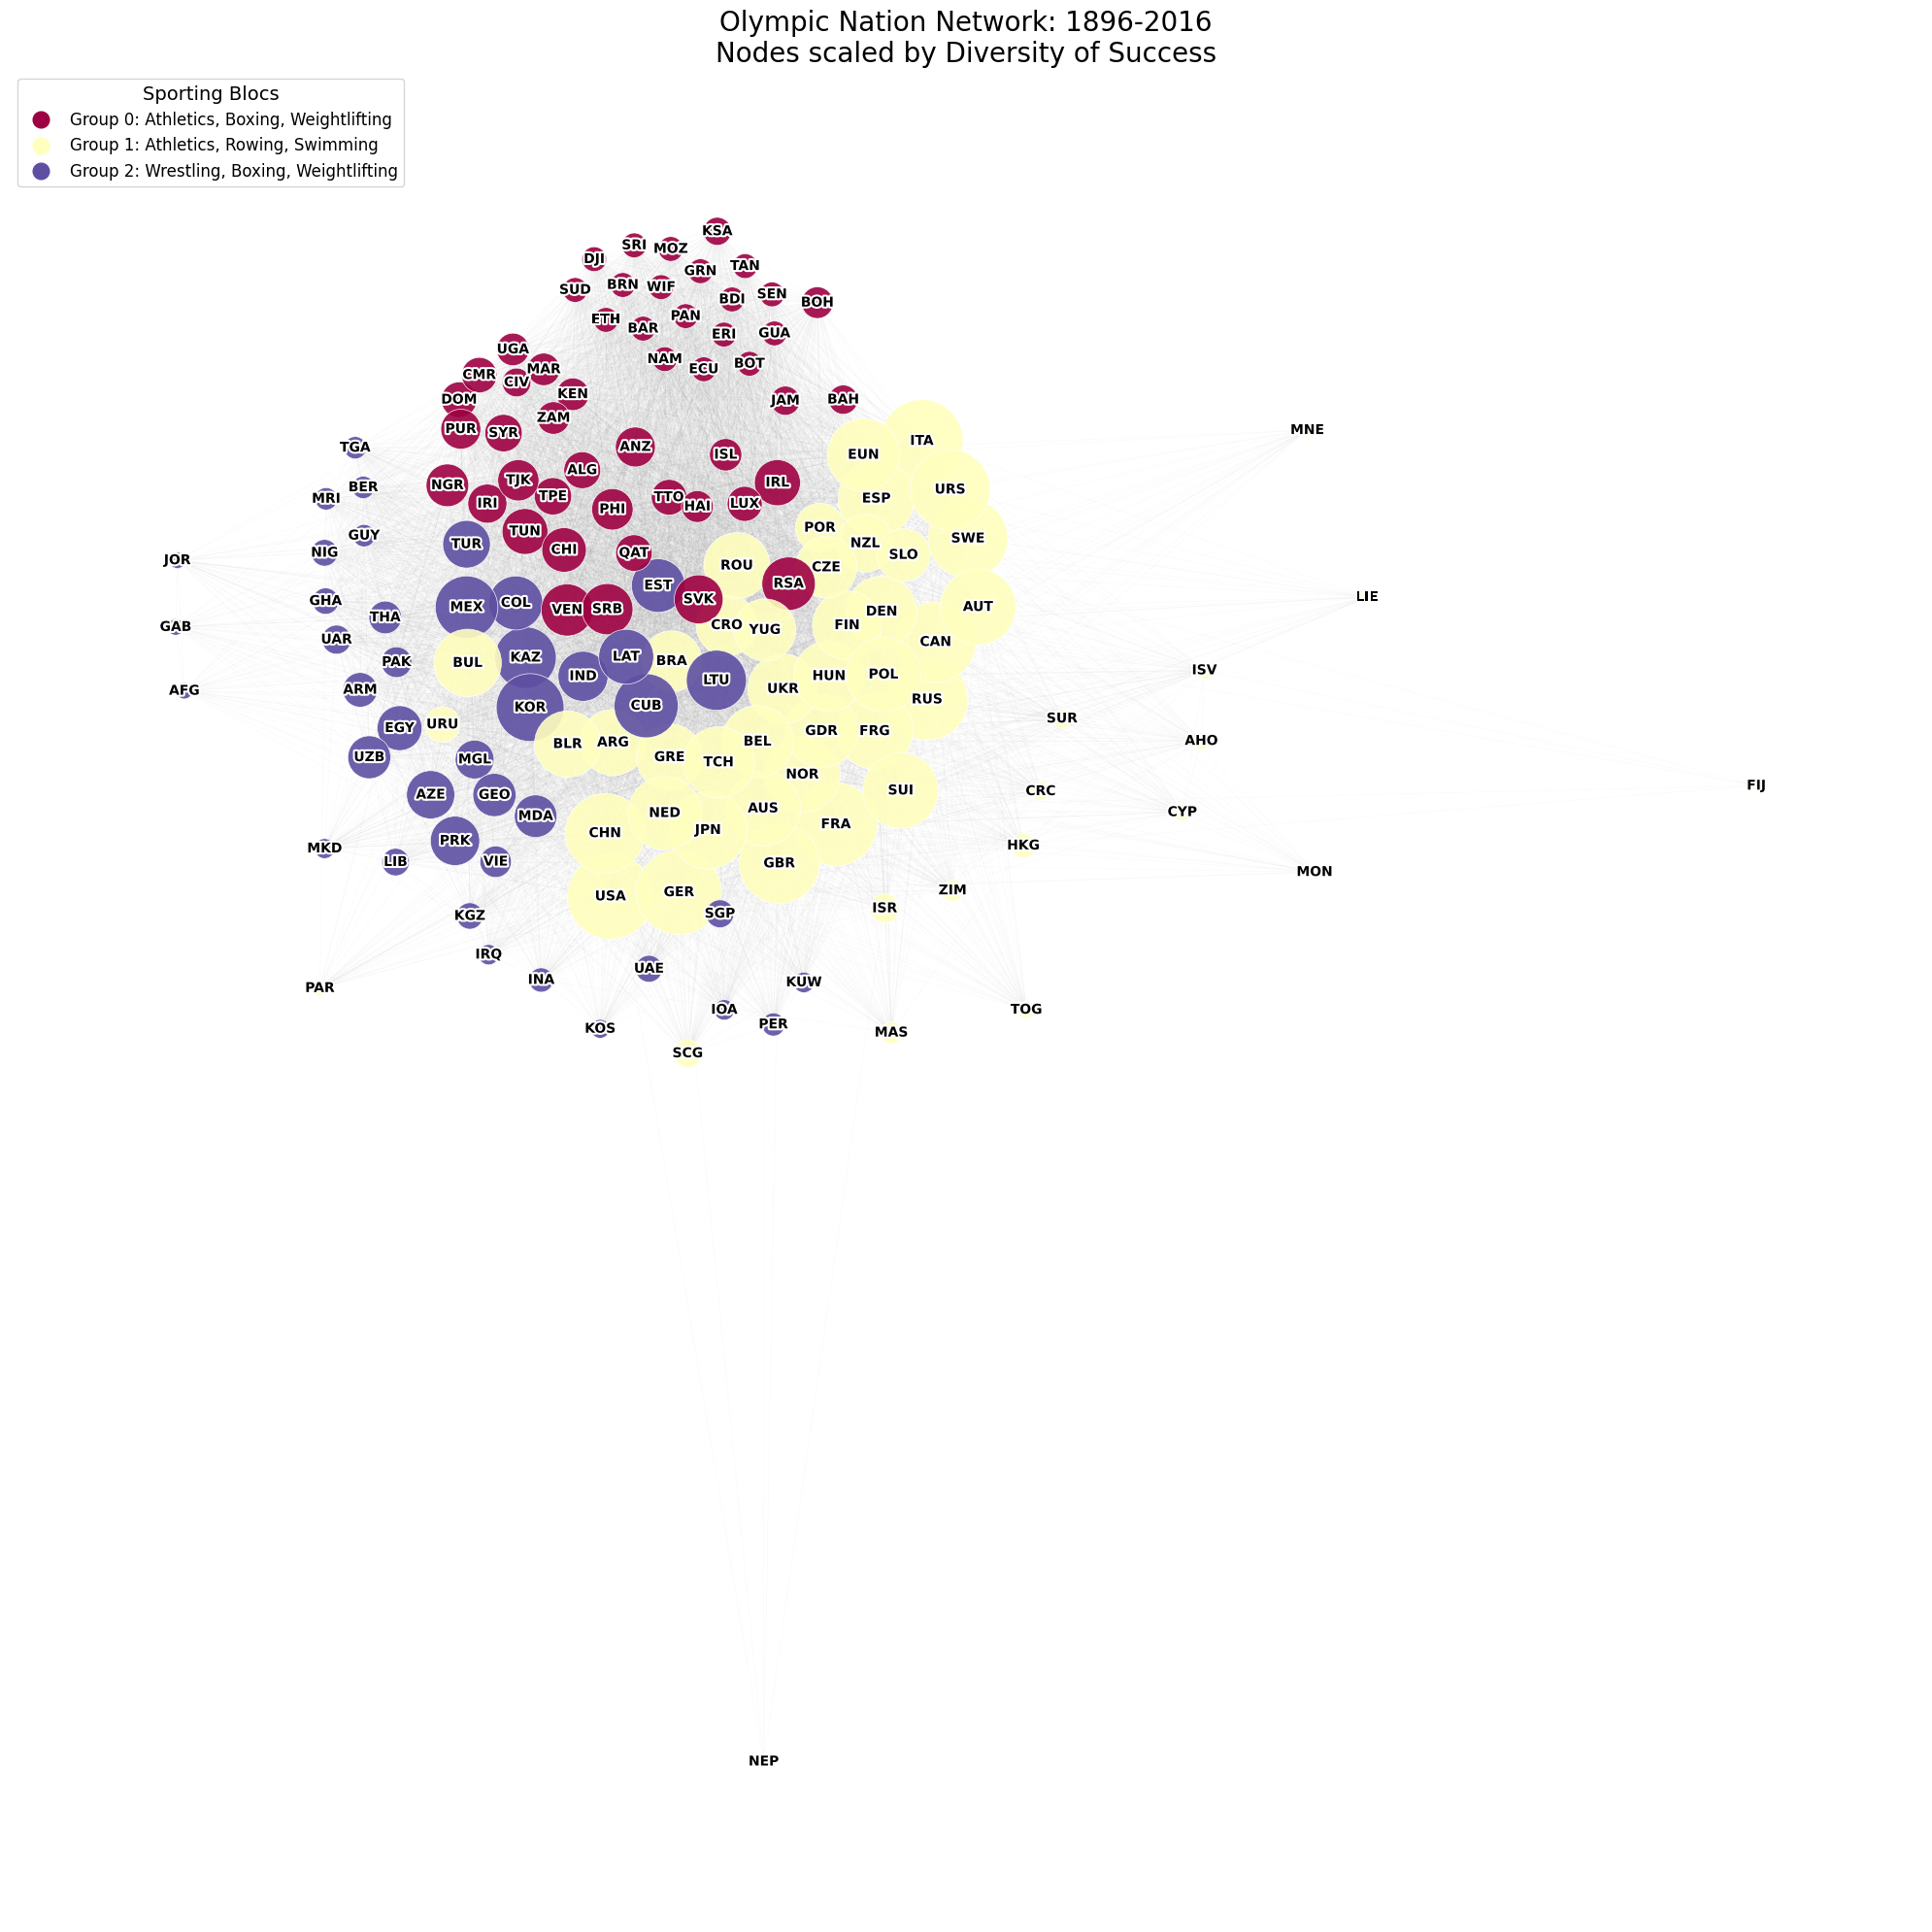

Group 0 Primary Sports:
Sports_List
Athletics        156
Boxing            62
Weightlifting     23
Wrestling         21
Swimming          20
Name: count, dtype: int64

Group 1 Primary Sports:
Sports_List
Athletics    457
Rowing       323
Swimming     307
Wrestling    297
Shooting     290
Name: count, dtype: int64

Group 2 Primary Sports:
Sports_List
Wrestling        99
Boxing           95
Weightlifting    74
Judo             59
Athletics        50
Name: count, dtype: int64



In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import matplotlib.lines as mlines
from itertools import combinations
from collections import Counter
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.centrality import eigenvector_centrality

# 1) Load the cleaned dataset
df_raw = pd.read_csv("cleaned_olympic_nation_year.csv")

# SET YOUR INTERVAL HERE
start_year, end_year = 1896, 2016
df_filtered = df_raw[(df_raw['Year'] >= start_year) & (df_raw['Year'] <= end_year)].copy()

# 2) DATA CLEANING & PREP
# Safely convert string lists to actual Python lists
df_filtered['Sports_List'] = df_filtered['Sports_List'].apply(eval)

# Map Sports to Nations
sport_to_nations = {}
for idx, row in df_filtered.iterrows():
    for sport in row['Sports_List']:
        if sport not in sport_to_nations:
            sport_to_nations[sport] = []
        sport_to_nations[sport].append(row['NOC'])

# Count shared sports for edges
edge_counts = Counter()
for sport, nations in sport_to_nations.items():
    for u, v in combinations(set(nations), 2):
        pair = tuple(sorted((u, v)))
        edge_counts[pair] += 1

# 3) BUILD GRAPH
G = nx.Graph()
for (u, v), w in edge_counts.items():
    G.add_edge(u, v, weight=w)

# 4) EIGENVECTOR CENTRALITY & LAYOUT
ec = eigenvector_centrality(G, weight='weight', max_iter=2000)

for u, v, d in G.edges(data=True):
    avg_c = (ec[u] + ec[v]) / 2.0
    # Higher centrality = weaker spring (more space)
    d['ec_weight'] = 1.0 / (avg_c + 1e-6)

# Increase k to push nodes further apart if it's still too crowded
pos = nx.spring_layout(G, weight='ec_weight', k=0.3, iterations=500, seed=42)

# 5) VISUAL ATTRIBUTES
deg = dict(G.degree(weight='weight'))
max_deg = max(deg.values())
node_sizes = [30 + (deg[n]/max_deg)*4000 for n in G.nodes()]

# Community Detection
comms = louvain_communities(G, weight='weight', seed=42)
partition = {node: i for i, comm in enumerate(comms) for node in comm}
node_colors = [partition[n] for n in G.nodes()]
unique_comms = sorted(list(set(node_colors)))
cmap = plt.cm.Spectral

# 6) DRAWING THE FIGURE
plt.figure(figsize=(20, 20))

# Edges (Very light alpha to show specialists clearly)
nx.draw_networkx_edges(G, pos, alpha=0.04, edge_color='gray', width=0.5)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=cmap,
    alpha=0.9,
    edgecolors='white',
    linewidths=0.5
)

# 7) ADD THE LEGEND WITH DYNAMIC NAMES
legend_handles = []
for i in unique_comms:
    comm_nodes = [n for n, c in partition.items() if c == i]
    # Identify the characteristic sports of this group
    comm_sports = df_filtered[df_filtered['NOC'].isin(comm_nodes)]['Sports_List'].explode()
    top_3 = ", ".join(comm_sports.value_counts().index[:3])

    color = cmap(i / (len(unique_comms) - 1)) if len(unique_comms) > 1 else cmap(0)
    line = mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                         markersize=12, label=f"Group {i}: {top_3}")
    legend_handles.append(line)

plt.legend(handles=legend_handles, loc='upper left', fontsize=12, title="Sporting Blocs", title_fontsize=14)

# 8) LABELING (Filter to Top 40 to avoid mess)
top_labels = sorted(deg, key=deg.get, reverse=True)[:]
for n in top_labels:
    x, y = pos[n]
    plt.text(x, y, n, fontsize=10, ha='center', va='center', fontweight='bold',
             path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])

plt.title(f"Olympic Nation Network: {start_year}-{end_year}\nNodes scaled by Diversity of Success", fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print text summary
for i, comm in enumerate(comms):
    comm_sports = df_filtered[df_filtered['NOC'].isin(comm)]['Sports_List'].explode()
    print(f"Group {i} Primary Sports:\n{comm_sports.value_counts().head(5)}\n")

# Time Series Analysis

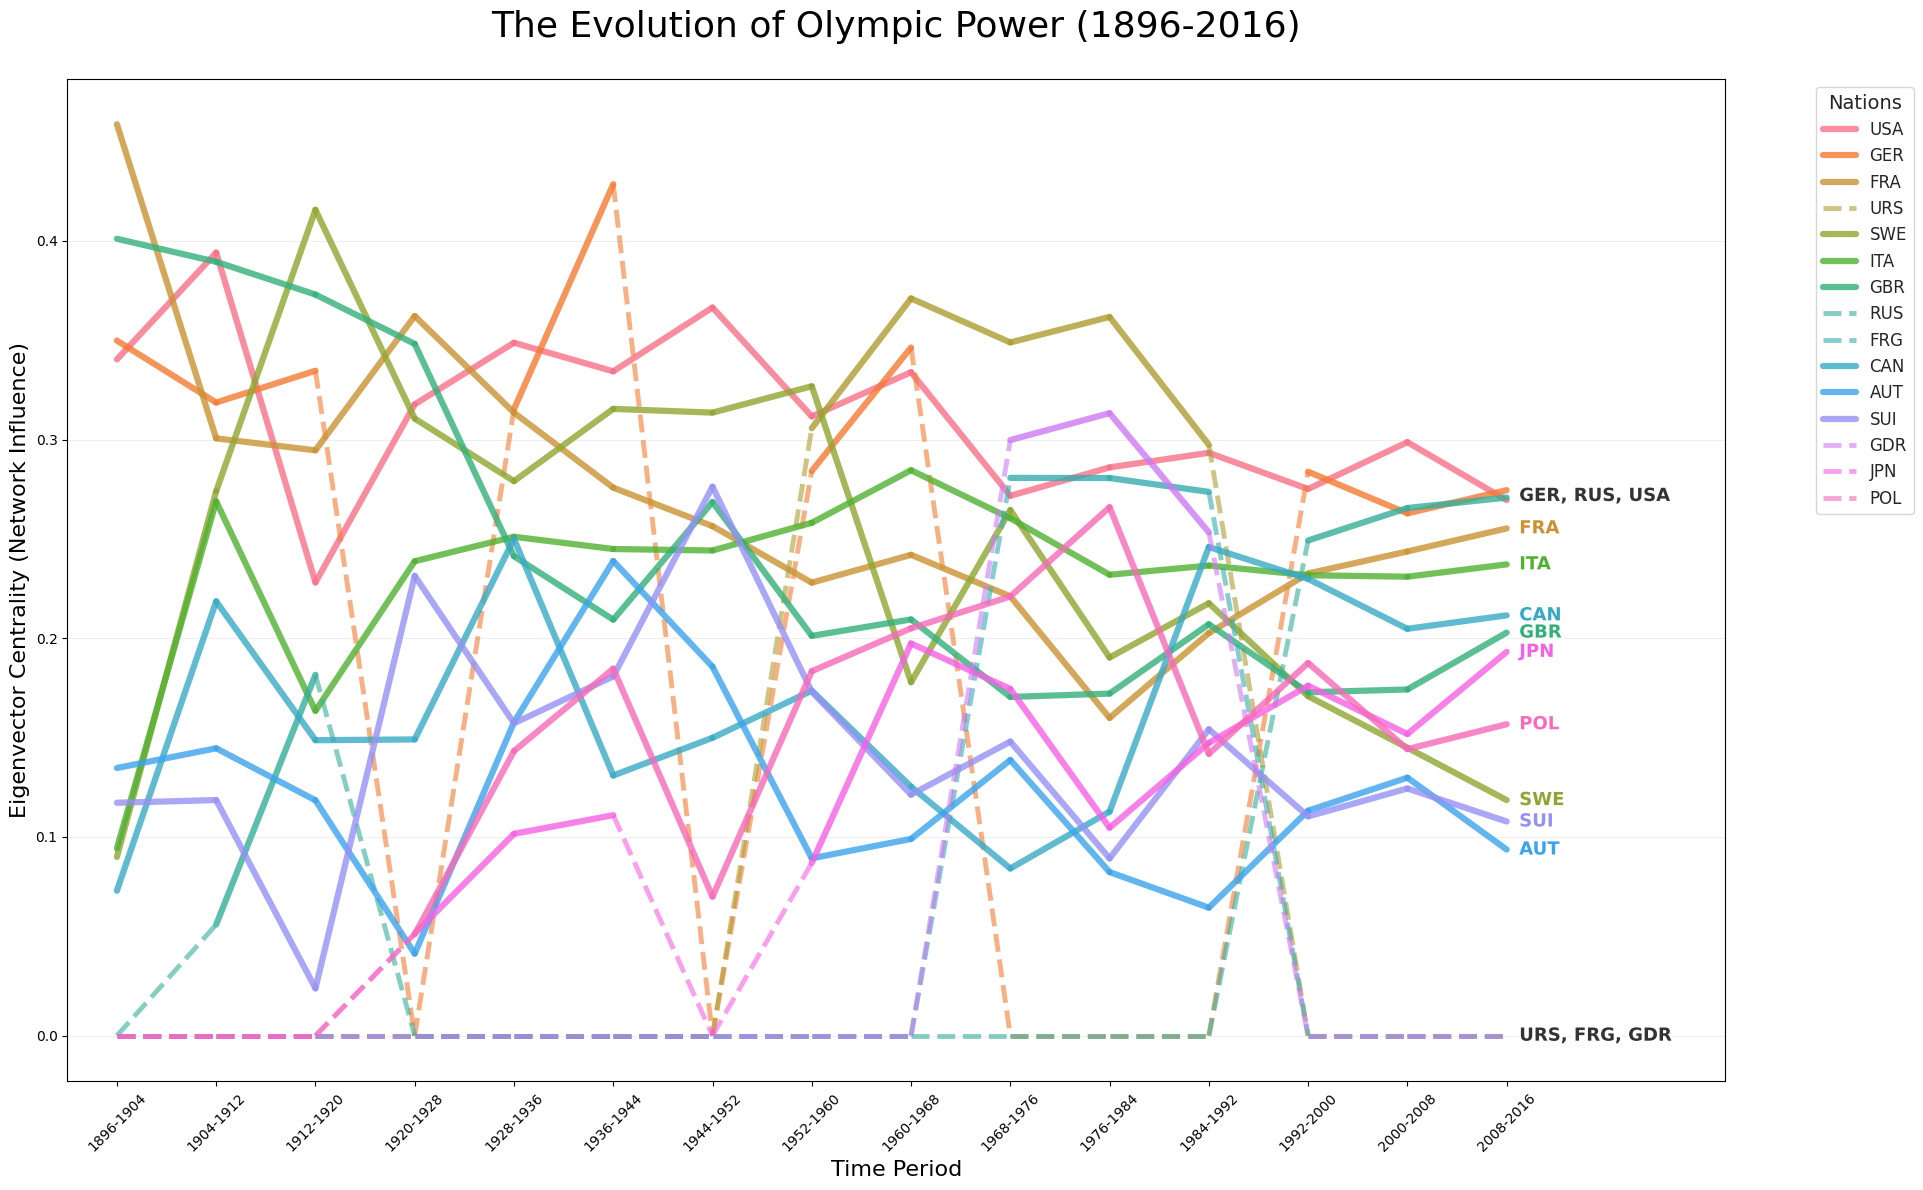

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from itertools import combinations
from collections import Counter

# 1) Load and Prep Data

df_raw = pd.read_csv("cleaned_olympic_nation_year.csv")
df_raw['Sports_List'] = df_raw['Sports_List'].apply(eval)

def get_centrality_for_period(df_slice):
    """Helper function to build a network and return eigenvector centrality scores"""
    if df_slice.empty: return {}

    sport_to_nations = {}
    for _, row in df_slice.iterrows():
        for sport in row['Sports_List']:
            sport_to_nations.setdefault(sport, []).append(row['NOC'])

    edge_counts = Counter()
    for nations in sport_to_nations.values():
        for u, v in combinations(set(nations), 2):
            edge_counts[tuple(sorted((u, v)))] += 1

    G = nx.Graph()
    for (u, v), w in edge_counts.items():
        G.add_edge(u, v, weight=w)

    if len(G) == 0: return {}
    try:
        return nx.eigenvector_centrality(G, weight='weight', max_iter=2000)
    except:
        return {}


num_nations_to_plot = 15
interval = 8

# 2) Identify Top Nations
df_ref = df_raw[(df_raw['Year'] >= 1896) & (df_raw['Year'] <= 2000)]
ref_centrality = get_centrality_for_period(df_ref)
top_nations = sorted(ref_centrality, key=ref_centrality.get, reverse=True)[:num_nations_to_plot]

# 3) Calculate Time-Series Data
years = sorted(df_raw['Year'].unique())
max_data_year = max(years)
history = []

for start in range(min(years), max_data_year, interval):
    end = start + interval

    display_end = min(end, max_data_year)

    if start >= max_data_year:
        continue

    df_slice = df_raw[(df_raw['Year'] >= start) & (df_raw['Year'] < end)]
    scores = get_centrality_for_period(df_slice)

    period_label = f"{start}-{display_end}"

    for noc in top_nations:
        history.append({
            'Period': period_label,
            'NOC': noc,
            'Centrality': scores.get(noc, 0)
        })

plot_df = pd.DataFrame(history)

# 4) Plotting
fig, ax = plt.subplots(figsize=(22, 12))
sns.set_style("white")

colors = sns.color_palette("husl", len(top_nations))
periods = list(plot_df['Period'].unique())
last_period = periods[-1]

final_points = []

for i, noc in enumerate(top_nations):
    subset = plot_df[plot_df['NOC'] == noc].reset_index(drop=True)
    if subset.empty: continue

    first_plot = True

    # --- SEGMENTED PLOTTING LOGIC (With Ghost Lines) ---
    for j in range(len(subset) - 1):
        p1 = subset.iloc[j]
        p2 = subset.iloc[j+1]

        x_seg = [p1['Period'], p2['Period']]
        y_seg = [p1['Centrality'], p2['Centrality']]

        lbl = noc if first_plot else "_"

        # 1. BOTH ACTIVE: Solid thick line
        if p1['Centrality'] > 0 and p2['Centrality'] > 0:
            ax.plot(x_seg, y_seg, color=colors[i], linewidth=4.5, alpha=0.8, label=lbl)
            first_plot = False

        # 2. TRANSITION: One is zero (Entering/Crashing) - Thick Dashed
        elif (p1['Centrality'] > 0 and p2['Centrality'] == 0) or \
             (p1['Centrality'] == 0 and p2['Centrality'] > 0):
            ax.plot(x_seg, y_seg, color=colors[i], linestyle='--', linewidth=3.5, alpha=0.6, label=lbl)
            first_plot = False

        # 3. GHOST: Both are zero - Faint thin dashed line along the floor
        elif p1['Centrality'] == 0 and p2['Centrality'] == 0:
            ax.plot(x_seg, y_seg, color=colors[i], linestyle='--', linewidth=3.5, alpha=0.6, label=lbl)
            first_plot = False

    # 5) Collect the last point for labeling
    last_row = subset.iloc[-1]
    final_points.append({
        'noc': noc,
        'val': last_row['Centrality'],
        'color': colors[i]
    })

# 6) SMART LABELING LOGIC (Group overlaps)
final_points = sorted(final_points, key=lambda x: x['val'], reverse=True)
threshold = 0.005
groups = []

if final_points:
    current_group = [final_points[0]]
    for p in final_points[1:]:
        if abs(p['val'] - current_group[-1]['val']) <= threshold:
            current_group.append(p)
        else:
            groups.append(current_group)
            current_group = [p]
    groups.append(current_group)

for group in groups:
    avg_val = sum(p['val'] for p in group) / len(group)
    combined_names = ", ".join([p['noc'] for p in group])

    label_color = group[0]['color'] if len(group) == 1 else "#333333"

    ax.text(
        last_period,
        avg_val,
        f"  {combined_names}",
        color=label_color,
        fontsize=13,
        fontweight='bold',
        va='center',
        ha='left',
        path_effects=[pe.withStroke(linewidth=4, foreground='white')]
    )

# 7) Final Formatting
plt.title(f"The Evolution of Olympic Power (1896-2016)", fontsize=26, pad=30)
plt.ylabel("Eigenvector Centrality (Network Influence)", fontsize=16)
plt.xlabel("Time Period", fontsize=16)

# Legend on the right
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Nations",
          fontsize=12, title_fontsize=14, frameon=True)

plt.xlim(left=-0.5, right=len(periods) + 1.2)
plt.grid(axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

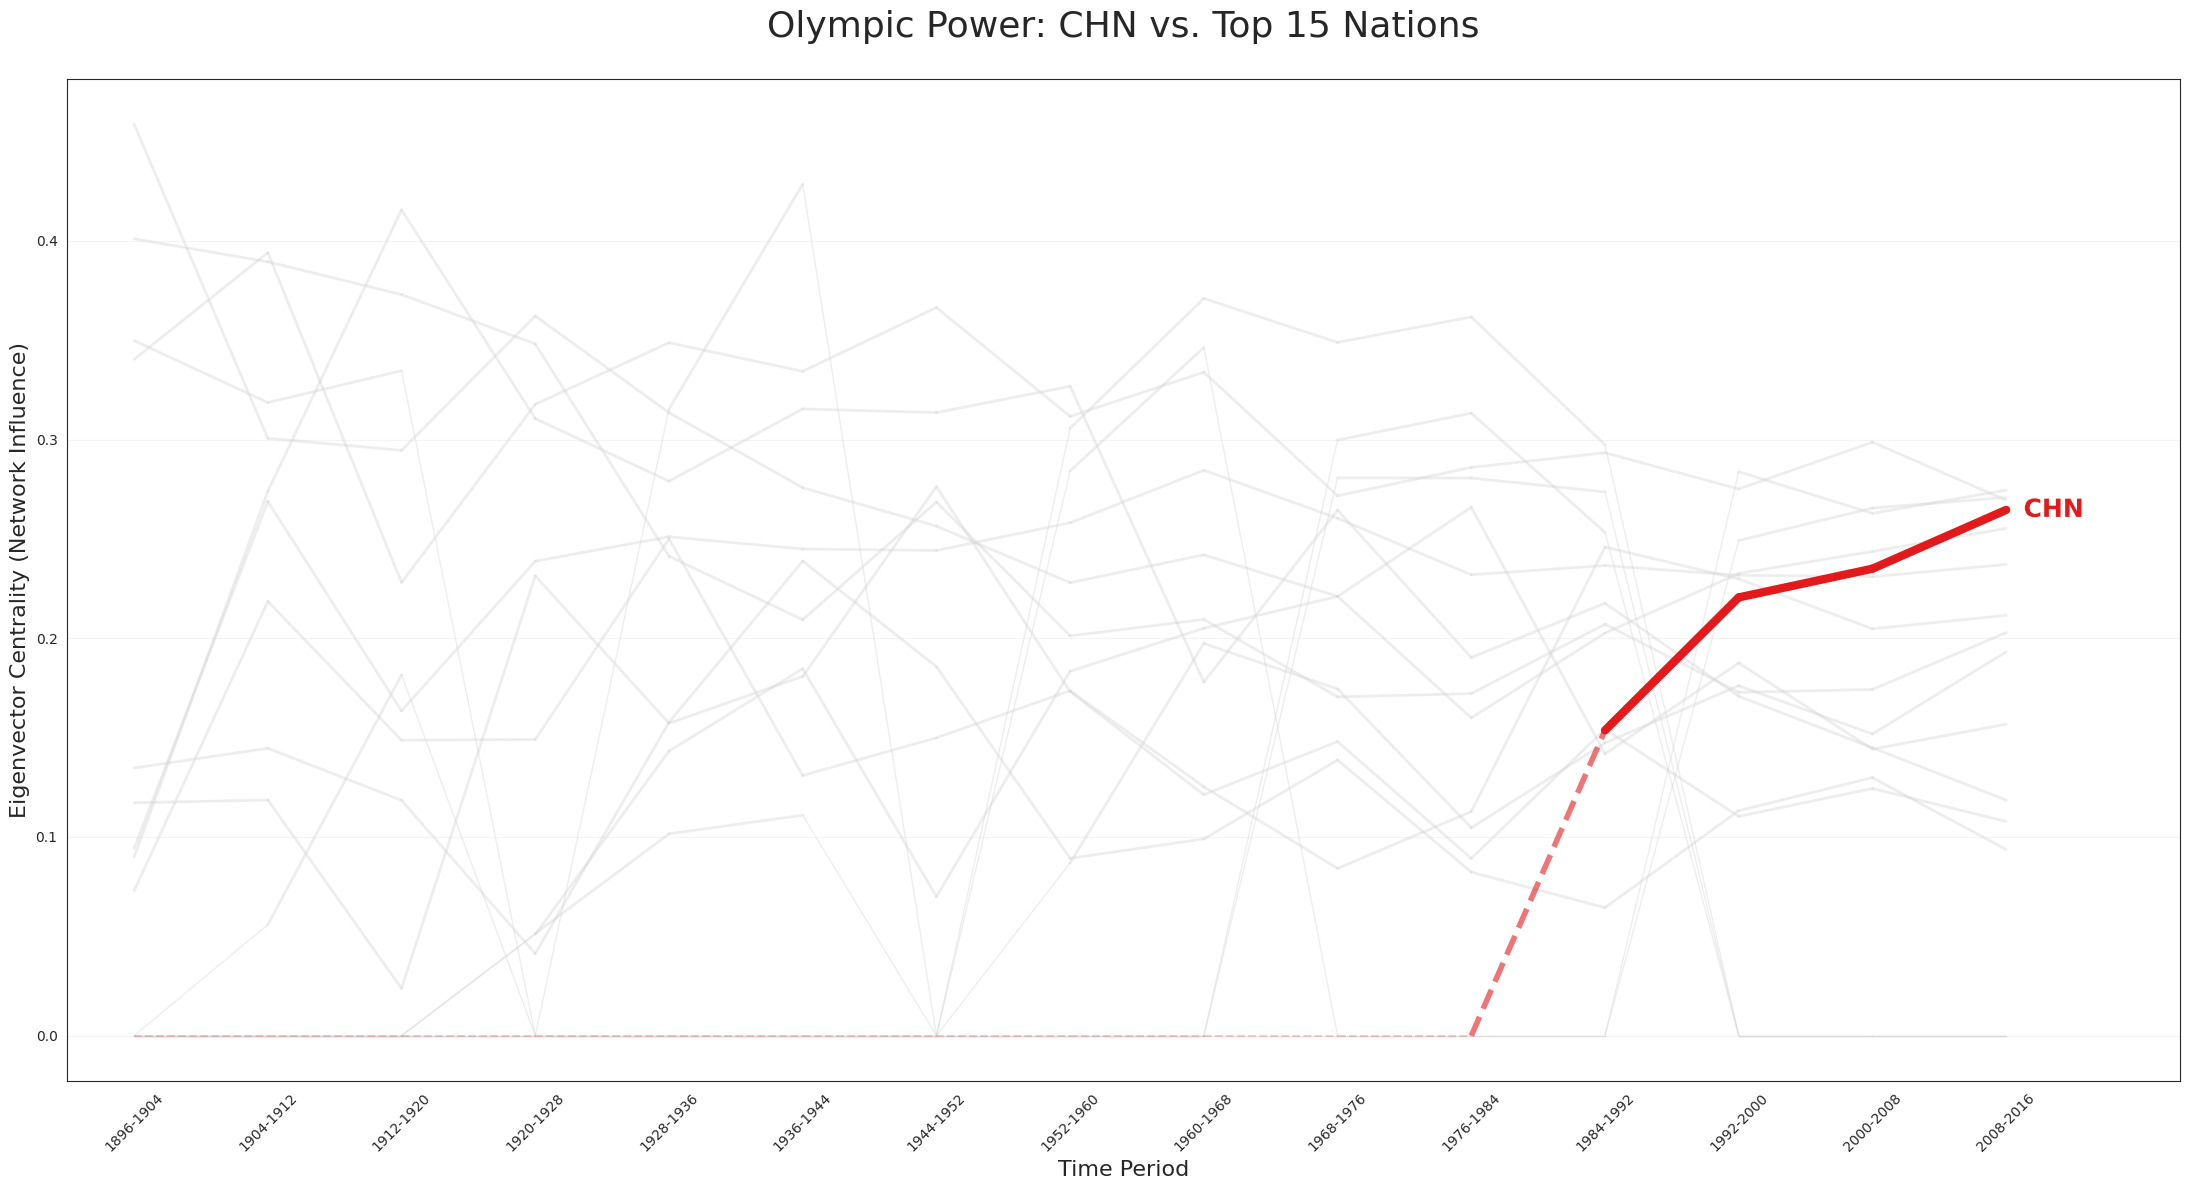

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from itertools import combinations
from collections import Counter

# 1) Setup functions and data
df_raw = pd.read_csv("cleaned_olympic_nation_year.csv")
df_raw['Sports_List'] = df_raw['Sports_List'].apply(eval)

def get_centrality_for_period(df_slice):
    if df_slice.empty: return {}
    sport_to_nations = {}
    for _, row in df_slice.iterrows():
        for sport in row['Sports_List']:
            sport_to_nations.setdefault(sport, []).append(row['NOC'])
    edge_counts = Counter()
    for nations in sport_to_nations.values():
        for u, v in combinations(set(nations), 2):
            edge_counts[tuple(sorted((u, v)))] += 1
    G = nx.Graph()
    for (u, v), w in edge_counts.items():
        G.add_edge(u, v, weight=w)
    if len(G) == 0: return {}
    try:
        return nx.eigenvector_centrality(G, weight='weight', max_iter=2000)
    except:
        return {}


highlight_noc = "CHN"
num_bg_nations = 15
interval = 8

# 2) Identify top nations (the grey backdrop)
df_ref = df_raw[(df_raw['Year'] >= 1896) & (df_raw['Year'] <= 2000)]
ref_centrality = get_centrality_for_period(df_ref)
top_nations = sorted(ref_centrality, key=ref_centrality.get, reverse=True)[:num_bg_nations]

nations_to_calc = list(set(top_nations + [highlight_noc]))

# 3) Calculate Time-Series Data
years = sorted(df_raw['Year'].unique())
max_data_year = max(years)
history = []

for start in range(min(years), max_data_year, interval):
    end = start + interval

    display_end = min(end, max_data_year)
    period_label = f"{start}-{display_end}"

    df_slice = df_raw[(df_raw['Year'] >= start) & (df_raw['Year'] < end)]
    scores = get_centrality_for_period(df_slice)

    for noc in nations_to_calc:
        history.append({
            'Period': period_label,
            'NOC': noc,
            'Centrality': scores.get(noc, 0)
        })

plot_df = pd.DataFrame(history)
periods = plot_df['Period'].unique()

# 4) Plotting
fig, ax = plt.subplots(figsize=(22, 12))
sns.set_style("white")

# plot background nations
for noc in top_nations:
    if noc == highlight_noc: continue
    subset = plot_df[plot_df['NOC'] == noc].reset_index(drop=True)

    for j in range(len(subset) - 1):
        p1, p2 = subset.iloc[j], subset.iloc[j+1]
        x_seg = [p1['Period'], p2['Period']]
        y_seg = [p1['Centrality'], p2['Centrality']]

        style = '-' if (p1['Centrality'] > 0 and p2['Centrality'] > 0) else '--'
        width = 2 if style == '-' else 1

        ax.plot(x_seg, y_seg, color='#D3D3D3', linewidth=width, alpha=0.4, zorder=1)

# Plot highligted nation
highlight_subset = plot_df[plot_df['NOC'] == highlight_noc].reset_index(drop=True)
highlight_color = "#E31A1C"

for j in range(len(highlight_subset) - 1):
    p1, p2 = highlight_subset.iloc[j], highlight_subset.iloc[j+1]
    x_seg = [p1['Period'], p2['Period']]
    y_seg = [p1['Centrality'], p2['Centrality']]

    if p1['Centrality'] > 0 and p2['Centrality'] > 0:
        ax.plot(x_seg, y_seg, color=highlight_color, linewidth=6, alpha=1.0, zorder=10)
    elif (p1['Centrality'] > 0 and p2['Centrality'] == 0) or (p1['Centrality'] == 0 and p2['Centrality'] > 0):
        ax.plot(x_seg, y_seg, color=highlight_color, linestyle='--', linewidth=4, alpha=0.6, zorder=9)
    elif p1['Centrality'] == 0 and p2['Centrality'] == 0:
        ax.plot(x_seg, y_seg, color=highlight_color, linestyle='--', linewidth=1.5, alpha=0.2, zorder=8)

# Add label at the end of the highlight line
last_p = highlight_subset.iloc[-1]
ax.text(
    last_p['Period'], last_p['Centrality'], f"  {highlight_noc}",
    color=highlight_color, fontsize=18, fontweight='bold', va='center',
    path_effects=[pe.withStroke(linewidth=5, foreground='white')], zorder=11
)

# 5) FINAL FORMATTING
plt.title(f"Olympic Power: {highlight_noc} vs. Top {num_bg_nations} Nations", fontsize=26, pad=30)
plt.ylabel("Eigenvector Centrality (Network Influence)", fontsize=16)
plt.xlabel("Time Period", fontsize=16)

plt.xlim(left=-0.5, right=len(periods) - 0.5 + 0.8)
plt.grid(axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation Between GDP and Dominance

Spearman's rho: 0.6351
P-value:        8.0358e-12

--- OLS REGRESSION SUMMARY (Unique Countries) ---
                            OLS Regression Results                            
Dep. Variable:        Log10_Dominance   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     70.76
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.34e-13
Time:                        14:28:12   Log-Likelihood:                -23.165
No. Observations:                  93   AIC:                             50.33
Df Residuals:                      91   BIC:                             55.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

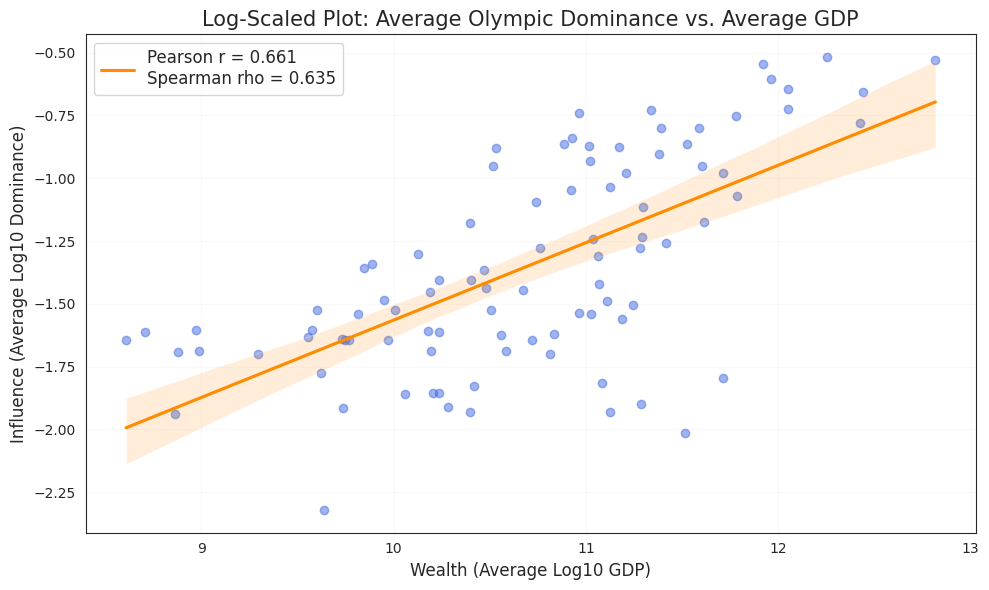

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Load and aggregate
df = pd.read_csv('centrality_and_gdp.csv')
df_unique = df.groupby('ISO_Code').agg({
    'Dominance': 'mean',
    'GDP': 'mean'
}).reset_index()

df_unique = df_unique[(df_unique['GDP'] > 0) & (df_unique['Dominance'] > 0)].dropna()

# 2. Transform (Log-Log)
df_unique['Log10_GDP'] = np.log10(df_unique['GDP'])
df_unique['Log10_Dominance'] = np.log10(df_unique['Dominance'])

# 3. Calculate correlations
rho, p_spearman = stats.spearmanr(df_unique['GDP'], df_unique['Dominance'])
r_loglog, p_pearson = stats.pearsonr(df_unique['Log10_GDP'], df_unique['Log10_Dominance'])

# 4. Run the regression
X = sm.add_constant(df_unique['Log10_GDP'])
y = df_unique['Log10_Dominance']
model = sm.OLS(y, X).fit()

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value:        {p_spearman:.4e}") # Using scientific notation for tiny p-values

print("\n--- OLS REGRESSION SUMMARY (Unique Countries) ---")
print(model.summary())

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.set_style("white")

legend_label = f'Pearson r = {r_loglog:.3f}\nSpearman rho = {rho:.3f}'

sns.regplot(data=df_unique, x='Log10_GDP', y='Log10_Dominance',
            scatter_kws={'alpha':0.5, 'color':'royalblue'},
            line_kws={'color':'darkorange', 'label': legend_label})

plt.title("Log-Scaled Plot: Average Olympic Dominance vs. Average GDP", fontsize=15)
plt.xlabel("Wealth (Average Log10 GDP)", fontsize=12)
plt.ylabel("Influence (Average Log10 Dominance)", fontsize=12)
plt.legend(frameon=True, fontsize=12, loc='upper left')
plt.grid(True, which='major', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

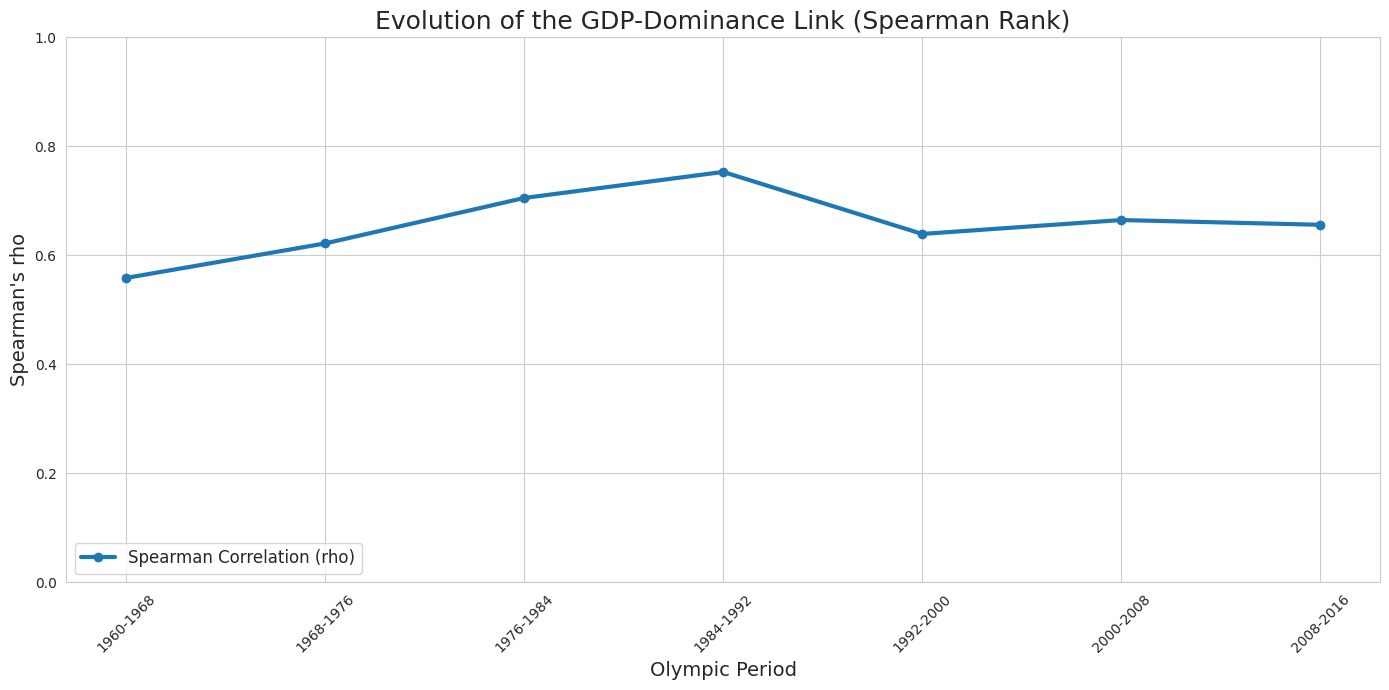

      Period  Spearman_Rho  N_Countries
0  1960-1968      0.558439           36
1  1968-1976      0.621756           36
2  1976-1984      0.705154           34
3  1984-1992      0.753022           52
4  1992-2000      0.639194           70
5  2000-2008      0.664711           69
6  2008-2016      0.655996           76


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND CLEAN
df = pd.read_csv('centrality_and_gdp.csv')

# Drop missing values
df = df.dropna(subset=['GDP', 'Dominance'])

# 2. CALCULATE CORRELATIONS PER PERIOD
periods = sorted(df['Period'].unique())
stats_history = []

for period in periods:
    subset = df[df['Period'] == period]

    if len(subset) > 5:
        # Spearman's rho calculation (rank-based)
        s_rho, _ = stats.spearmanr(subset['GDP'], subset['Dominance'])

        stats_history.append({
            'Period': period,
            'Spearman_Rho': s_rho,
            'N_Countries': len(subset)
        })

stats_df = pd.DataFrame(stats_history)

# 3. VISUALIZATION
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# FIX: Use a raw string r'...' to prevent \r from being treated as a carriage return
plt.plot(stats_df['Period'], stats_df['Spearman_Rho'], marker='o',
         linewidth=3, label=r'Spearman Correlation (rho)', color='#1f77b4')

# Formatting
plt.ylim(0, 1) # Correlation coefficients scale
plt.title("Evolution of the GDP-Dominance Link (Spearman Rank)", fontsize=18)

# FIX: Use a raw string here as well
plt.ylabel(r"Spearman's rho", fontsize=14)
plt.xlabel("Olympic Period", fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.savefig('spearman_evolution.png') # Saving the plot
plt.show()

print(stats_df)